<a href="https://colab.research.google.com/github/scardenol/Numerical_Analysis_2026/blob/main/Taller%202/1_backward_induction_bellman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 2 - Punto 1

- Programar escenarios discretos como el ejemplo de clase (camino más corto de secuencias) de Programación Dinámica: Optimalidad de Bellman (Inducción hacia atrás); para mostrar que la programación dinámica es mejor que la fuerza bruta.
- Plantear un experimento para mostrar esto. *Hint:* usar big $\mathcal{O}$.
- Discusión de cómo se parece/difiere con Dijkstra.

**Nota:**
1. el ejemplo de clase era un grafo acíclico dirigido, es decir, un grafo dirigido en donde siempre se puede alcanzar el nodo final por algún camino. Se asume este mismo tipo para todo.
2. Los grafos se pueden representar como matrices y así es como se asume que el usuario pasa la información del problema.

Enunciado oficial

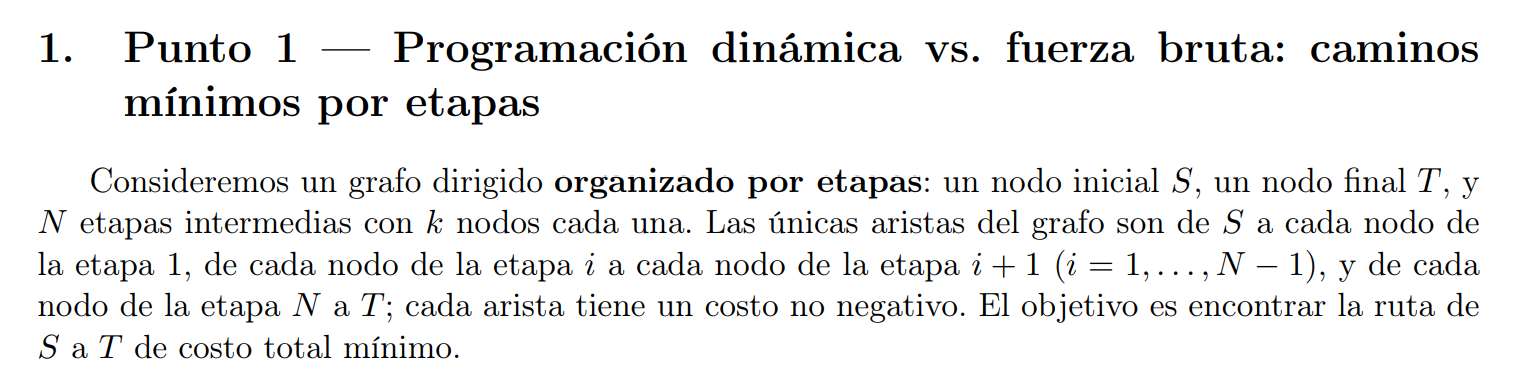

In [1]:
# Cargar librerías
import math
import random
import time
import networkx as nx
import heapq # Dijkstra, encuentra mínimos más rápidos en una lista
import matplotlib.pyplot as plt

# Estructura de datos y visualización

In [2]:
# Funciones auxiliares para convertir una matriz a un objeto grafo y visualizar
def matriz_a_grafo(matriz, etiquetas):
    """
    Construye un grafo dirigido como objeto DiGraph de networkx a partir de una
    matriz de costo + etiquetas de nodos.
    matriz[i][j] = costo de la arista i -> j (0 significa "sin arista").
    """
    G = nx.DiGraph() # Instanciar el grafo (objeto DiGraph de networkx)
    G.add_nodes_from(etiquetas) # Agregar nodos de las etiquetas
    n = len(etiquetas) # Número de etiquetas

    # Ciclo principal para recorrer elemento por elemento de la matriz
    for i in range(n): # iterar filas de la matriz
        for j in range(n): # iterar columnas de la matriz
            w = matriz[i][j] # tomar el peso del elemento (i,j)=(fila, columna)
            if w != 0: # si el peso NO es 0
                G.add_edge(etiquetas[i], etiquetas[j], weight=w) # agregar la arista

    # Si el grafo resultante NO es acíclico dirigido, panic
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("El grafo tiene que ser acíclico para poder usar inducción hacia atrás.")
    return G

def graficar_grafo(G, path=None, title="Graph", source=None, save_path=None):
    """
    Organiza los nodos en columnas según la distancia más corta (en número
    de saltos) desde la fuente (`source`) (detectada automáticamente como el
    único nodo con grado de entrada 0 si no se pasa). Esto coincide con la forma
    en que estos grafos de Bellman se dibujan normalmente a mano (S, luego cada
    nodo alcanzable directamente desde S, luego la siguiente "etapa", ...).
    """

    # 1. Determinar el nodo fuente (origen)
    # Si no se especifica 'source', se busca el nodo raíz único (in_degree == 0).
    # Si hay múltiples raíces o ninguna, se usa el primer nodo del ordenamiento topológico.
    if source is None:
        roots = [n for n in G.nodes if G.in_degree(n) == 0]
        source = roots[0] if len(roots) == 1 else list(nx.topological_sort(G))[0]

    # 2. Asignar capas/columnas a los nodos basadas en la distancia en saltos
    # Calcular la distancia más corta (número mínimo de aristas) desde 'source' a cada nodo
    dist = nx.single_source_shortest_path_length(G, source)

    # Asignar una capa por defecto a nodos inalcanzables desde la fuente
    for n in G.nodes:
        dist.setdefault(n, max(dist.values(), default=0) + 1)

    # Agrupar los nodos según su nivel/capa (distancia)
    layers = {}
    for n, d in dist.items():
        layers.setdefault(d, []).append(n)

    # 3. Calcular las coordenadas de posición (x, y) para cada nodo
    # x = índice de la capa (columna)
    # y = alineación vertical centrada de los nodos dentro de su respectiva capa
    pos = {}
    for x in sorted(layers):
        layer = layers[x]
        n = len(layer)
        for y, node in enumerate(layer):
            pos[node] = (x, -(y - (n - 1) / 2))

    # 4. Configuración breve de la visualización
    # Ajustar el tamaño de la figura dinámicamente según el número de capas
    fig, ax = plt.subplots(figsize=(1.9 * len(layers) + 2, 5))

    # Identificar las aristas que forman parte de la ruta destacada ('path')
    path_edges = set(zip(path, path[1:])) if path else set()

    # Definir colores y grosores diferenciados para aristas y nodos del camino óptimo/destacado
    edge_colors = ["crimson" if e in path_edges else "gray" for e in G.edges()]
    edge_widths = [2.8 if e in path_edges else 1.1 for e in G.edges()]
    node_colors = [
        "crimson" if path and n in path else "steelblue" for n in G.nodes()
    ]

    # 5. Renderizar la estructura del grafo (nodos y aristas con curvatura)
    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,  # Nota: 'with_etiquetas' corregido a 'with_labels' estándar de NetworkX
        node_color=node_colors,
        font_color="white",
        font_weight="bold",
        node_size=850,
        edge_color=edge_colors,
        width=edge_widths,
        arrowsize=18,
        connectionstyle="arc3,rad=0.06",  # Ligera curvatura en los arcos para evitar solapamientos
    )

    # 6. Dibujar las etiquetas de peso en las aristas (pesos)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=9,
        label_pos=0.4,  # Ajustar posición relativa del texto a lo largo de la arista (para evitar overlapping)
    )

    # 7. Título y guardado opcional de la imagen
    ax.set_title(title)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

In [3]:
# Ejemplo
etiquetas = ["S", "A", "B", "C", "D", "T"]
matriz = [
  #  S  A  B  C  D  T
    [0, 2, 4, 0, 0, 0], # S
    [0, 0, 0, 3, 6, 0], # A
    [0, 0, 0, 1, 2, 0], # B
    [0, 0, 0, 0, 0, 4], # C
    [0, 0, 0, 0, 0, 2], # D
    [0, 0, 0, 0, 0, 0], # T
]
G_class = matriz_a_grafo(matriz, etiquetas)

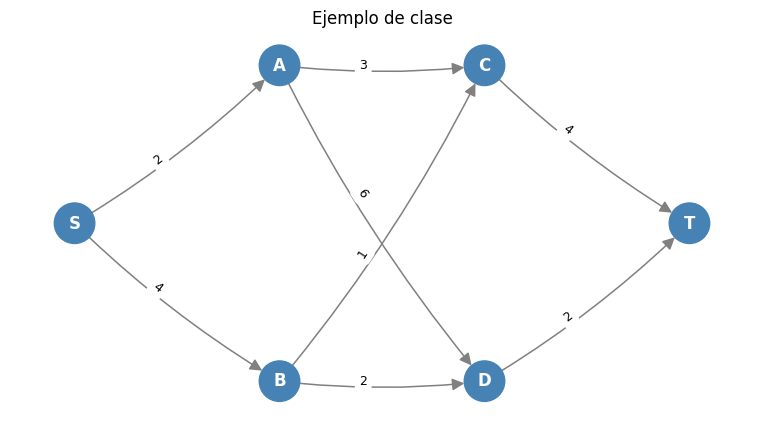

In [4]:
# Ejemplo
graficar_grafo(G_class, title="Ejemplo de clase")

# Implementación de algoritmos: Bellman, Fuerza Bruta y Dijkstra

## 1) Método de Backward Induction de Bellman
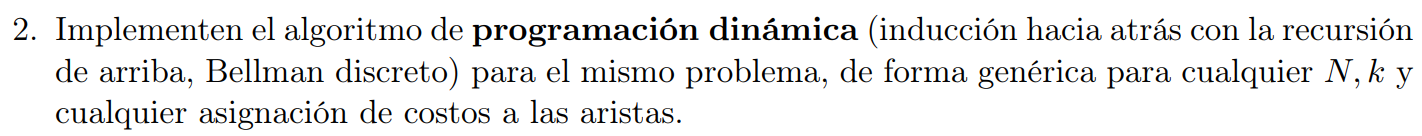

In [5]:
# Función principal
def bellman_backward_induction(G, target):
    """
    V(nodo) = costo mínimo desde `nodo` hasta `destino` (`target`);
    politica(nodo) = mejor siguiente salto. Procesa los nodos en orden
    topológico INVERSO, igual que en el ejemplo de clase (comienza en el nodo
    target T, avanza hacia atrás). Cada arista se examina exactamente una vez ->
    O(|V| + |E|).
    """
    # 1. Obtener el ordenamiento topológico del grafo
    order = list(nx.topological_sort(G))

    # 2. Inicializar el valor del costo de todos los nodos en infinito y el destino en 0
    V = {node: math.inf for node in G.nodes}
    V[target] = 0.0
    policy = {}

    # 3. Recorrer los nodos en orden inverso (desde el destino hacia el origen)
    for node in reversed(order):
        if node == target:
            continue

        best_cost, best_next = math.inf, None

        # Evaluar todas las aristas salientes del nodo actual
        for _, nxt, data in G.out_edges(node, data=True):
            candidate = data["weight"] + V[nxt]
            if candidate < best_cost:
                best_cost, best_next = candidate, nxt

        # Guardar el costo mínimo y el siguiente nodo óptimo en la política
        V[node] = best_cost
        policy[node] = best_next

    return V, policy


# Funciones auxiliares

# Función para reconstruir la secuencia de nodos del camino óptimo
def reconstruct_path(policy, source, target):
    path = [source]
    node = source

    # Seguir las decisiones óptimas de la política hasta alcanzar el destino
    while node != target:
        node = policy[node]
        path.append(node)

    return path


# Función para resolver el camino más corto mediante programación dinámica
def dp_shortest_path(G, source, target):
    # Calcula la función de valor y la política óptima, luego reconstruye la ruta
    V, policy = bellman_backward_induction(G, target)
    path = reconstruct_path(policy, source, target)

    return path, V[source], V

## 2) Método de fuerza bruta
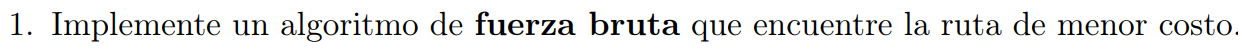

In [6]:
# Función auxiliar para calcular el costo total de un camino
def path_cost(G, path):
    # Suma los pesos de todas las aristas consecutivas en la secuencia del camino
    return sum(G[u][v]["weight"] for u, v in zip(path, path[1:]))


# Función de fuerza bruta para encontrar el camino más corto
def brute_force_shortest_path(G, source, target):
    """
    Enumera todos los caminos simples de S -> T y elige el de menos peso.
    Peor caso: exponencial en el número de nodos (un DAG denso por capas con
    `ancho` nodos/capa y `L` capas tiene ancho**(L-1) caminos).
    """
    best_path, best_cost = None, math.inf

    # Evaluar la suma de pesos de cada camino posible entre origen y destino
    for path in nx.all_simple_paths(G, source, target):
        c = path_cost(G, path)
        if c < best_cost:
            best_cost, best_path = c, path

    return best_path, best_cost

## 3) Método de Dijkstra
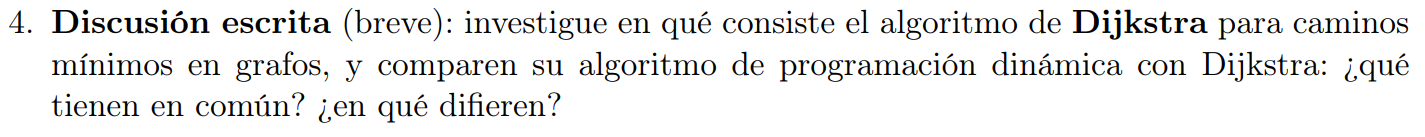

Básicamente, el algoritmo de Dijkstra encuentra el camino más corto (o de menos costo) desde un nodo origen *source* hacia los demás nodos explorando el grafo de forma *greedy*, i.e., elige el nodo inmediato de menor costo, sin mirar más pasos hacia adelante. Mantiene una estimación de la distancia mínima en cada nodo y, en cada paso, elige el nodo no visitado con la menor distancia acumulada utilizando una cola de prioridad (min-heap).

<div align="center">

<br>

| Criterio | Cosas en común |
| :---: | :--- |
| **Principio de Optimalidad** | Técnicamente, ambos usan el *Principio de Optimalidad de Bellman*: cualquier subcamino de una ruta óptima también debe ser óptimo. |
| **Relajación de aristas** | Ambos actualizan las distancias comparando caminos candidatos mediante la operación de relajación (función $V(\cdot)$: $V(u) = \min(V(u), \text{peso}(u, v) + V(v))$. |
| **Ponderación positiva** | Ambos garantizan encontrar el camino óptimo de forma eficiente cuando las aristas tienen pesos no negativos ($w \ge 0$). |

</div>

<br>

<div align="center">

| Criterio | Diferencias |
| :---: | :--- |
| **Estructura del grafo** | **Programación Dinámica:** Pide estrictamente un Grafo Acíclico Dirigido (DAG) para establecer un orden topológico.<br>**Dijkstra:** Funciona con **cualquier grafo** (incluso con ciclos), siempre que los pesos sean no negativos. |
| **Estrategia de ordenamiento** | **Programación Dinámica:** Procesa los nodos en un orden topológico estático fijo a priori (inducción hacia atrás).<br>**Dijkstra:** Descubre el orden de procesamiento dinámicamente mientras itera mediante una cola de prioridad (*min-heap*). |
| **Complejidad computacional** | **Programación Dinámica:** $O(|V| + |E|)$ (tiempo lineal, ya que se ahorra la cola de prioridad).<br>**Dijkstra:** $O((|V| + |E|) \log |V|)$ debido al costo logarítmico de insertar y extraer elementos de la cola de prioridad. |
| **Dirección del análisis** | **Programación Dinámica:** Inducción hacia atrás (*backward*), desde el destino hacia el origen.<br>**Dijkstra:** Búsqueda hacia adelante (*forward*), desde el origen hacia el resto del grafo. |

</div>

In [7]:
# Algoritmo de Dijkstra para encontrar el camino más corto
def dijkstra_shortest_path(G, source, target):
    """
    Dijkstra hacia adelante clásico desde `source`. Funciona en CUALQUIER
    grafo (permite ciclos) siempre que pesos >= 0. A diferencia de Bellman
    en la inducción hacia atrás, NO usa ni necesita un orden topológico. En su
    lugar, descubre un orden de procesamiento "seguro" mientras itera: finaliza
    repetidamente el nodo no visitado que tenga la menor distancia tentativa
    actual, a través de una cola de prioridad (min-heap).

    Complejidad: O((|V| + |E|) log |V|), i.e.,el mismo trabajo de relajación que la
    Programación Dinámica en DAGs, más un factor log|V| por la cola de prioridad
    que la inducción hacia atrás se ahorra al conocer de antemano un orden seguro.
    """
    # 1. Inicializar las distancias en infinito y la estructura para reconstruir la ruta
    dist = {node: math.inf for node in G.nodes}
    dist[source] = 0.0
    prev = {}
    visited = set()

    # Cola de prioridad que almacena pares (distancia_tentativa, nodo)
    pq = [(0.0, source)]

    # 2. Exploración del grafo guiada por la menor distancia acumulada
    while pq:
        d, u = heapq.heappop(pq)

        if u in visited:
            continue
        visited.add(u)

        # Interrumpir la búsqueda si ya alcanzamos el nodo destino
        if u == target:
            break

        # Evaluar y relajar las aristas salientes del nodo actual
        for _, v, data in G.out_edges(u, data=True):
            nd = d + data["weight"]
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))

    # 3. Reconstruir la secuencia del camino desde el destino hasta el origen
    path = [target]
    node = target
    while node != source:
        node = prev[node]
        path.append(node)
    path.reverse()

    return path, dist[target], dist

# Validación con el ejemplo de clase

V(nodo): {'S': 8.0, 'A': 7.0, 'B': 4.0, 'C': 4.0, 'D': 2.0, 'T': 0.0}
Óptimo Bellman:   S -> B -> D -> T | costo = 8.0
Óptimo Fuerza Bruta:  S -> B -> D -> T | costo = 8


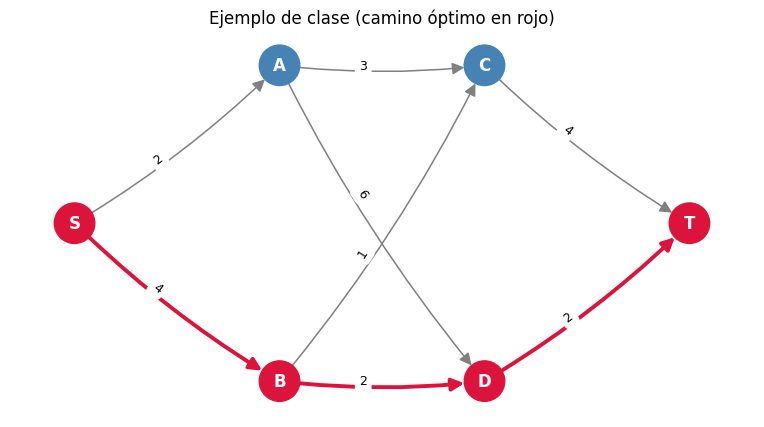

In [8]:
etiquetas = ["S", "A", "B", "C", "D", "T"]
matriz = [
  #  S  A  B  C  D  T
    [0, 2, 4, 0, 0, 0], # S
    [0, 0, 0, 3, 6, 0], # A
    [0, 0, 0, 1, 2, 0], # B
    [0, 0, 0, 0, 0, 4], # C
    [0, 0, 0, 0, 0, 2], # D
    [0, 0, 0, 0, 0, 0], # T
]
G_class = matriz_a_grafo(matriz, etiquetas)

path_dp, cost_dp, V = dp_shortest_path(G_class, "S", "T")
print("V(nodo):", {k: (v if math.isfinite(v) else "inf") for k, v in V.items()})
print("Óptimo Bellman:  ", " -> ".join(path_dp), "| costo =", cost_dp)

path_bf, cost_bf = brute_force_shortest_path(G_class, "S", "T")
print("Óptimo Fuerza Bruta: ", " -> ".join(path_bf), "| costo =", cost_bf)
assert path_dp == path_bf and cost_dp == cost_bf

graficar_grafo(G_class, path=path_dp, title="Ejemplo de clase (camino óptimo en rojo)")

El resultado coincide con el de clase.

# Experimentación

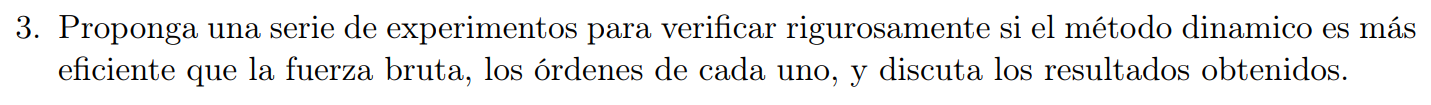

Para comparar los 3 algoritmos, se propone ejecutarlos en múltiples grafos densos de distintos tamaños y ver el tiempo de ejcución de cada algoritmo versus el tamaño de los grafos. Se piensan en grafos con un único nodo de partida y un único nodo de llegada, entonces lo que crece son los nodos intermedios en "filas" (*width*, crecimiento horizontal) y en "columnas" o "capas" (*layers*, c).

La idea es simular múltiples grafos acíclicos, dirigidos, de pesos aleatorios y totalmente conectados (densos). Para esto, se crea una función `random_layered_dag()` donde el usuario le puede pasar:
- `n_layers`: el número de capas o "columnas" de nodos que se crean entre el nodo de partida y el de llegada.
- `width`: el número de "filas" de nodos que se crean entre el nodo de partida y el de llegada.
- `weight_range`: el intervalo cerrado de valores de pesos enteros para muestrear aleatoriamente (uniforme). Fijado en $[1,10]$ por defecto.
- `seed`: semilla del PRNG para hacer el generador reproducible. Fijada en 0 por defecto.

Para el experimento, se mantiene un número de filas fijo `width=3` y simplemente se aumenta el número de capas de 2 a 12. Esto resulta en evaluar 11 grafos con distintos niveles de densidad que crece de manera exponencial.

## 1) Generador de DAGs aleatorios estratificados

In [9]:
# Generador aleatorio estratificado de grafos acíclicos dirigidos (DAGs)
def random_layered_dag(n_layers, width, weight_range=(1, 10), seed=0):
    """
    S -> (capa 1, `width` nodos) -> (capa n_layers) -> T, donde cada nodo está
    totalmente conectado con todos los nodos de la siguiente capa. El número de
    caminos distintos S-T = width**(n_layers-1) —exponencial en n_layers—
    mientras que el número de ARISTAS (lo que procesa la Programación Dinámica)
    solo crece linealmente.
    """
    rng = random.Random(seed) # Fijar la semilla del PRNG para reproducibilidad
    G = nx.DiGraph() # Instanciar el grafo (objeto DiGraph de networkx)

    # Definir la estructura de capas (Origen 'S', capas intermedias y Destino 'T')
    layers = (
        [["S"]]
        + [[f"L{l}_{i}" for i in range(width)] for l in range(1, n_layers+1)]
        + [["T"]]
    )

    # Agregar los nodos al grafo capa por capa
    for layer in layers:
        G.add_nodes_from(layer)

    # Conectar de forma totalmente densa cada capa con la subsecuente mediante pesos aleatorios
    for a, b in zip(layers, layers[1:]):
        for u in a:
            for v in b:
                G.add_edge(u, v, weight=rng.randint(*weight_range))

    return G

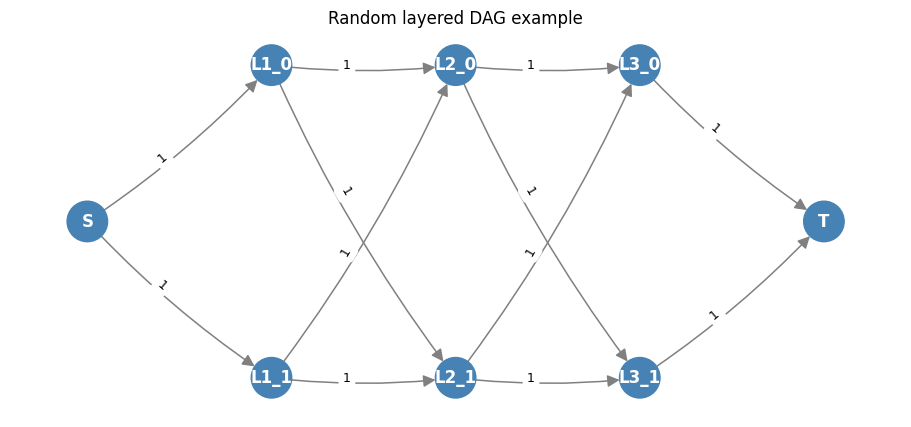

In [10]:
# Ejemplo
G_test = random_layered_dag(n_layers=3, width=2, weight_range=(1, 1), seed=42)
graficar_grafo(G_test, title="Random layered DAG example")

## 2) Experimento principal: comparación de métodos

In [11]:
width = 3
layer_range = range(2, 13)
dp_times, bf_times, dij_times, n_paths = [], [], [], []

for L in layer_range:
    G_exp = random_layered_dag(n_layers=L, width=width, seed=1)

    t0 = time.perf_counter()
    dp_shortest_path(G_exp, "S", "T")
    dp_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    dijkstra_shortest_path(G_exp, "S", "T")
    dij_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    brute_force_shortest_path(G_exp, "S", "T")
    bf_times.append(time.perf_counter() - t0)

    n_paths.append(width ** (L - 1))
    print(f"capas={L:2d}  nodos={G_exp.number_of_nodes():3d}  |E|={G_exp.number_of_edges():4d}  "
          f"caminos={width**(L-1):>8d}  Bellman={dp_times[-1]:.6f}s  Dijkstra={dij_times[-1]:.6f}s  "
          f"F. Bruta={bf_times[-1]:.6f}s")

capas= 2  nodos=  8  |E|=  15  caminos=       3  Bellman=0.000185s  Dijkstra=0.000078s  F. Bruta=0.000275s
capas= 3  nodos= 11  |E|=  24  caminos=       9  Bellman=0.000153s  Dijkstra=0.000069s  F. Bruta=0.000645s
capas= 4  nodos= 14  |E|=  33  caminos=      27  Bellman=0.000188s  Dijkstra=0.000084s  F. Bruta=0.004583s
capas= 5  nodos= 17  |E|=  42  caminos=      81  Bellman=0.002319s  Dijkstra=0.000141s  F. Bruta=0.011527s
capas= 6  nodos= 20  |E|=  51  caminos=     243  Bellman=0.000261s  Dijkstra=0.000147s  F. Bruta=0.023252s
capas= 7  nodos= 23  |E|=  60  caminos=     729  Bellman=0.000358s  Dijkstra=0.000194s  F. Bruta=0.123863s
capas= 8  nodos= 26  |E|=  69  caminos=    2187  Bellman=0.000318s  Dijkstra=0.000211s  F. Bruta=0.285540s
capas= 9  nodos= 29  |E|=  78  caminos=    6561  Bellman=0.000384s  Dijkstra=0.000278s  F. Bruta=1.033006s
capas=10  nodos= 32  |E|=  87  caminos=   19683  Bellman=0.000369s  Dijkstra=0.000261s  F. Bruta=2.684213s
capas=11  nodos= 35  |E|=  96  camino

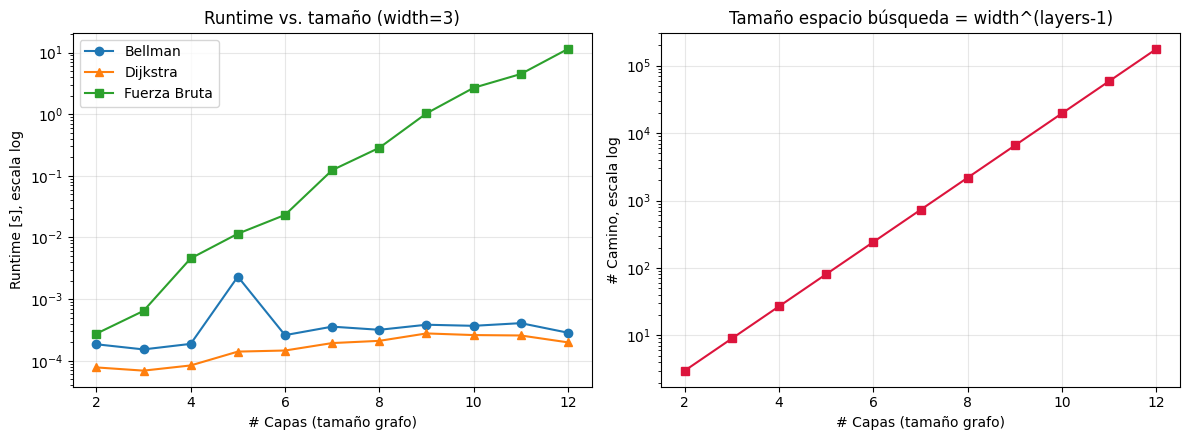

In [12]:
# Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(layer_range), dp_times, "o-", label="Bellman")
axes[0].plot(list(layer_range), dij_times, "^-", label="Dijkstra")
axes[0].plot(list(layer_range), bf_times, "s-", label="Fuerza Bruta")
axes[0].set_yscale("log")
axes[0].set_xlabel("# Capas (tamaño grafo)")
axes[0].set_ylabel("Runtime [s], escala log")
axes[0].set_title(f"Runtime vs. tamaño (width={width})")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(layer_range), n_paths, "s-", color="crimson")
axes[1].set_yscale("log")
axes[1].set_xlabel("# Capas (tamaño grafo)")
axes[1].set_ylabel("# Camino, escala log")
axes[1].set_title("Tamaño espacio búsqueda = width^(layers-1)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Los resultados observados reflejan súper claro el comportamiento teórico de los 3 algoritmos al escalar el tamaño del grafo:

- Fuerza Bruta: mientras que el grafo apenas crece de forma lineal (pasa de 8 a 38 nodos y de 15 a 105 aristas), el número de caminos $S \to T$ sufre un crecimiento exponencial ($3^{\text{capas}-1}$), saltando de solo 3 rutas en 2 capas a 177,147 rutas en 12 capas. El tiempo de Fuerza Bruta escala con ese crecimiento: empieza en $0.27\text{ ms}$ y se dispara hasta los 11.46 segundos. Esto muestra que la fuerza bruta (enumeración exhaustiva) se vuelve inviable o poco práctico "rápidamente".

- Eficiencia de Bellman y Dijkstra: ambos algoritmos se mantienen planos por debajo de $1\text{ ms}$ en casi toda el experimento (excepto por un pico de $2.31\text{ ms}$ en Bellman para 5 capas atribuido a overhead o basura de Python). Al iterar sobre la estructura de nodos y aristas ($O(\vert{}V\vert{} + \vert{}E\vert{})$) en vez de listar caminos enteros, la explosión del espacio de búsqueda resulta totalmente transparente.

- Dijkstra vs. Bellman: Dijkstra resulta ser un poco más rápido que Bellman de forma consistente (rondando entre $0.069\text{ ms}$ y $0.278\text{ ms}$). Aunque teóricamente Bellman debería ganar por no pagar el sobrecosto de la cola de prioridad ($\log \vert{}V\vert{}$), esto se atribuye a que en grafos así de "pequeños" (aunque "densos") el overhead de Python procesando la inducción hacia atrás pesa más que la implementación optimizada en C que usa heapq en Dijkstra.

En conclusión, el experimento demuestra cómo la Programación Dinámica de Bellman y Dijkstra dominan por completo la complejidad exponencial del problema, encontrando el camino más corto en milisegundos.